# CMEMS to vertical profile

This example shows how to extract a vertical transect from a Copernicus
Marine (CMEMS) NetCDF file and save it as a **dfsu vertical profile** —
an unstructured mesh format commonly used as boundary conditions in MIKE
hydrodynamic models.

## Setup

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import mikeio
from mikeio.spatial import GeometryFMVerticalProfile
from mikecore.DfsuFile import DfsuFileType

## Load CMEMS data

This example uses a small Baltic Sea subset downloaded with the
[Copernicus Marine
Toolbox](https://help.marine.copernicus.eu/en/collections/9080063-copernicus-marine-toolbox):

In [2]:
ds_cmems = xr.open_dataset("../../data/cmems_mod_bal_phy_anfc_P1D.nc")
ds_cmems

<xarray.Dataset> Size: 564kB
Dimensions: (time: 3, depth: 29, latitude: 54, longitude: 15)
Coordinates:
 * time (time) datetime64[ns] 24B 2026-03-01 2026-03-02 2026-03-03
 * depth (depth) float32 116B 0.5016 1.516 2.548 ... 91.31 103.8 117.6
 * latitude (latitude) float32 216B 59.07 59.09 59.11 ... 59.92 59.94 59.96
 * longitude (longitude) float32 60B 23.26 23.29 23.32 ... 23.6 23.63 23.65
Data variables:
 thetao (time, depth, latitude, longitude) float32 282kB ...
 so (time, depth, latitude, longitude) float32 282kB ...
Attributes:
 Conventions: CF-1.11
 title: CMEMS NEMO daily integrated model fields
 institution: Baltic MFC, PU Swedish Meteorological and Hydrological...
 source: CMEMS BAL MFC NEMO model output converted to NetCDF
 contact: servicedesk.cmems@mercator-ocean.eu
 references: https://marine.copernicus.eu/
 comment: Data on cropped native product grid. Horizontal veloci...
 subset:source: ARCO data downloaded from the Marine Data Store using ...
 subset:productId: BALTICSEA_ANALYSISFORECAST_PHY_003_006
 subset:datasetId: cmems_mod_bal_phy_anfc_P1D-m_202411
 subset:date: 2026-03-15T17:14:04.336Z xarray.Dataset Dimensions: time : 3 depth : 29 latitude : 54 longitude : 15 Coordinates: (4) time (time) datetime64[ns] 2026-03-01 2026-03-02 2026-03-03 standard_name : time long_name : Time axis : T array(['2026-03-01T00:00:00.000000000', '2026-03-02T00:00:00.000000000',
 '2026-03-03T00:00:00.000000000'], dtype='datetime64[ns]') depth (depth) float32 0.5016 1.516 2.548 ... 103.8 117.6 standard_name : depth long_name : Depth units : m unit_long : Meters axis : Z positive : down array([ 0.501646, 1.515992, 2.548084, 3.602298, 4.684081, 5.8002 ,
 6.959055, 8.171057, 9.449085, 10.809036, 12.27047 , 13.857369,
 15.59901 , 17.530924, 19.695944, 22.145256, 24.939384, 28.148958,
 31.85507 , 36.148987, 41.130913, 46.907536, 53.588184, 61.27954 ,
 70.079216, 80.06874 , 91.30695 , 103.82471 , 117.622 ],
 dtype=float32) latitude (latitude) float32 59.07 59.09 59.11 ... 59.94 59.96 standard_name : latitude long_name : Latitude units : degrees_north unit_long : Degrees North axis : Y array([59.07466 , 59.091328, 59.107994, 59.12466 , 59.141327, 59.157993,
 59.174656, 59.191322, 59.20799 , 59.224655, 59.24132 , 59.257988,
 59.274654, 59.291317, 59.307983, 59.32465 , 59.341316, 59.357983,
 59.37465 , 59.391315, 59.407978, 59.424644, 59.44131 , 59.457977,
 59.474644, 59.49131 , 59.507973, 59.52464 , 59.541306, 59.557972,
 59.57464 , 59.591305, 59.60797 , 59.624634, 59.6413 , 59.657967,
 59.674633, 59.6913 , 59.707966, 59.724632, 59.741295, 59.75796 ,
 59.774628, 59.791294, 59.80796 , 59.824627, 59.84129 , 59.857956,
 59.874622, 59.89129 , 59.907955, 59.92462 , 59.941288, 59.95795 ],
 dtype=float32) longitude (longitude) float32 23.26 23.29 23.32 ... 23.63 23.65 standard_name : longitude long_name : Longitude units : degrees_east unit_long : Degrees East axis : X array([23.264078, 23.291857, 23.319635, 23.347414, 23.37519 , 23.40297 ,
 23.430748, 23.458527, 23.486305, 23.514084, 23.54186 , 23.56964 ,
 23.597418, 23.625196, 23.652975], dtype=float32) Data variables: (2) thetao (time, depth, latitude, longitude) float32 ... units : degree_Celsius standard_name : sea_water_potential_temperature long_name : Potential temperature unit_long : degree Celsius [70470 values with dtype=float32] so (time, depth, latitude, longitude) float32 ... units : 1e-3 standard_name : sea_water_salinity long_name : Salinity unit_long : 1e-3 [70470 values with dtype=float32] Attributes: (11) Conventions : CF-1.11 title : CMEMS NEMO daily integrated model fields institution : Baltic MFC, PU Swedish Meteorological and Hydrological Institute source : CMEMS BAL MFC NEMO model output converted to NetCDF contact : servicedesk.cmems@mercator-ocean.eu references : https://marine.copernicus.eu/ comment : Data on cropped native product grid. Horizontal velocities destaggered subset:source : ARCO data downloaded from the Marine Data Store using the MyOcean Data Portal subs

## Define a transect

Define a transect as evenly-spaced points between two endpoints, using
the native grid resolution.

In [3]:
lon_start, lat_start = 23.6, 59.3
lon_end, lat_end = 23.6, 59.6
n_points = 20  # tip: infer from grid resolution, e.g. int(transect_length / grid_res) + 1

transect_lon = np.linspace(lon_start, lon_end, n_points)
transect_lat = np.linspace(lat_start, lat_end, n_points)

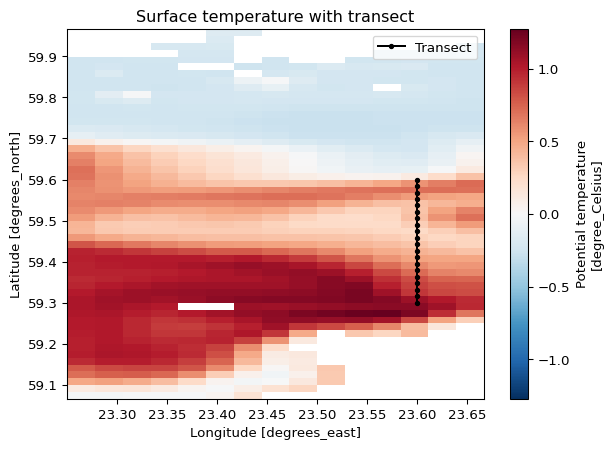

In [4]:
fig, ax = plt.subplots()
ds_cmems["thetao"].isel(time=0, depth=0).plot(ax=ax)
ax.plot(transect_lon, transect_lat, "k-o", markersize=3, label="Transect")
ax.legend()
ax.set_title("Surface temperature with transect");

## Extract data along the transect

Select the nearest grid point for each transect position using xarray.

In [5]:
ds_transect = ds_cmems.sel(
    latitude=xr.DataArray(transect_lat, dims="points"),
    longitude=xr.DataArray(transect_lon, dims="points"),
    method="nearest",
)

depth = ds_cmems.depth.values
time = ds_cmems.time.values
n_times = len(time)
n_depths = len(depth)

ds_transect

<xarray.Dataset> Size: 14kB
Dimensions: (time: 3, depth: 29, points: 20)
Coordinates:
 * time (time) datetime64[ns] 24B 2026-03-01 2026-03-02 2026-03-03
 * depth (depth) float32 116B 0.5016 1.516 2.548 ... 91.31 103.8 117.6
 latitude (points) float32 80B 59.31 59.31 59.32 ... 59.57 59.59 59.61
 longitude (points) float32 80B 23.6 23.6 23.6 23.6 ... 23.6 23.6 23.6 23.6
Dimensions without coordinates: points
Data variables:
 thetao (time, depth, points) float32 7kB ...
 so (time, depth, points) float32 7kB ...
Attributes:
 Conventions: CF-1.11
 title: CMEMS NEMO daily integrated model fields
 institution: Baltic MFC, PU Swedish Meteorological and Hydrological...
 source: CMEMS BAL MFC NEMO model output converted to NetCDF
 contact: servicedesk.cmems@mercator-ocean.eu
 references: https://marine.copernicus.eu/
 comment: Data on cropped native product grid. Horizontal veloci...
 subset:source: ARCO data downloaded from the Marine Data Store using ...
 subset:productId: BALTICSEA_ANALYSISFORECAST_PHY_003_006
 subset:datasetId: cmems_mod_bal_phy_anfc_P1D-m_202411
 subset:date: 2026-03-15T17:14:04.336Z xarray.Dataset Dimensions: time : 3 depth : 29 points : 20 Coordinates: (4) time (time) datetime64[ns] 2026-03-01 2026-03-02 2026-03-03 standard_name : time long_name : Time axis : T array(['2026-03-01T00:00:00.000000000', '2026-03-02T00:00:00.000000000',
 '2026-03-03T00:00:00.000000000'], dtype='datetime64[ns]') depth (depth) float32 0.5016 1.516 2.548 ... 103.8 117.6 standard_name : depth long_name : Depth units : m unit_long : Meters axis : Z positive : down array([ 0.501646, 1.515992, 2.548084, 3.602298, 4.684081, 5.8002 ,
 6.959055, 8.171057, 9.449085, 10.809036, 12.27047 , 13.857369,
 15.59901 , 17.530924, 19.695944, 22.145256, 24.939384, 28.148958,
 31.85507 , 36.148987, 41.130913, 46.907536, 53.588184, 61.27954 ,
 70.079216, 80.06874 , 91.30695 , 103.82471 , 117.622 ],
 dtype=float32) latitude (points) float32 59.31 59.31 59.32 ... 59.59 59.61 standard_name : latitude long_name : Latitude units : degrees_north unit_long : Degrees North axis : Y array([59.307983, 59.307983, 59.32465 , 59.341316, 59.357983, 59.37465 ,
 59.391315, 59.407978, 59.424644, 59.44131 , 59.457977, 59.474644,
 59.49131 , 59.507973, 59.52464 , 59.541306, 59.557972, 59.57464 ,
 59.591305, 59.60797 ], dtype=float32) longitude (points) float32 23.6 23.6 23.6 ... 23.6 23.6 23.6 standard_name : longitude long_name : Longitude units : degrees_east unit_long : Degrees East axis : X array([23.597418, 23.597418, 23.597418, 23.597418, 23.597418, 23.597418,
 23.597418, 23.597418, 23.597418, 23.597418, 23.597418, 23.597418,
 23.597418, 23.597418, 23.597418, 23.597418, 23.597418, 23.597418,
 23.597418, 23.597418], dtype=float32) Data variables: (2) thetao (time, depth, points) float32 ... units : degree_Celsius standard_name : sea_water_potential_temperature long_name : Potential temperature unit_long : degree Celsius [1740 values with dtype=float32] so (time, depth, points) float32 ... units : 1e-3 standard_name : sea_water_salinity long_name : Salinity unit_long : 1e-3 [1740 values with dtype=float32] Attributes: (11) Conventions : CF-1.11 title : CMEMS NEMO daily integrated model fields institution : Baltic MFC, PU Swedish Meteorological and Hydrological Institute source : CMEMS BAL MFC NEMO model output converted to NetCDF contact : servicedesk.cmems@mercator-ocean.eu references : https://marine.copernicus.eu/ comment : Data on cropped native product grid. Horizontal velocities destaggered subset:source : ARCO data downloaded from the Marine Data Store using the MyOcean Data Portal subset:productId : BALTICSEA_ANALYSISFORECAST_PHY_003_006 subset:datasetId : cmems_mod_bal_phy_anfc_P1D-m_202411 subset:date : 2026-03-15T17:14:04.336Z

## Build the vertical profile mesh

CMEMS data values are cell-centered — each `(depth, point)` is an
element value. The nodes sit at the boundaries between cells.

### Nodes

Compute node positions at the interfaces between depth levels and
between horizontal points.

In [6]:
# Vertical interfaces: surface, midpoints between levels, bottom
z_interfaces = np.concatenate(
    [[0], (depth[:-1] + depth[1:]) / 2, [depth[-1] + (depth[-1] - depth[-2]) / 2]]
)

# Horizontal interfaces: half-cell before first, midpoints, half-cell after last
half_dlon = (transect_lon[1] - transect_lon[0]) / 2
half_dlat = (transect_lat[1] - transect_lat[0]) / 2
lon_interfaces = np.concatenate(
    [[transect_lon[0] - half_dlon], (transect_lon[:-1] + transect_lon[1:]) / 2, [transect_lon[-1] + half_dlon]]
)
lat_interfaces = np.concatenate(
    [[transect_lat[0] - half_dlat], (transect_lat[:-1] + transect_lat[1:]) / 2, [transect_lat[-1] + half_dlat]]
)

n_nodes_per_col = n_depths + 1

# Build node coordinates: column-major, bottom-to-top
node_coords = np.column_stack([
    np.repeat(lon_interfaces, n_nodes_per_col),
    np.repeat(lat_interfaces, n_nodes_per_col),
    np.tile(-z_interfaces[::-1], n_points + 1),
])

### Elements

Each CMEMS cell maps to one element. Skip cells with NaN (below
seafloor).

In [7]:
# Seafloor mask: NaN marks cells below the seabed (any variable works, all share the same mask)
mask = ds_transect["so"].isel(time=0).values

# Build full grid of (point, layer) indices, then mask out seafloor
pi_all = np.repeat(np.arange(n_points), n_depths)
li_all = np.tile(np.arange(n_depths), n_points)
di_all = n_depths - 1 - li_all  # depth index (deepest first in mesh)
valid = ~np.isnan(mask[di_all, pi_all])
pi_valid, li_valid, di_valid = pi_all[valid], li_all[valid], di_all[valid]

# Node indices for each quad element: [bottom-left, bottom-right, top-right, top-left]
bl = pi_valid * n_nodes_per_col + li_valid
element_table = [
    np.array([b, b + n_nodes_per_col, b + n_nodes_per_col + 1, b + 1])
    for b in bl
]

### Geometry

In [8]:
geometry = GeometryFMVerticalProfile(
    node_coordinates=node_coords,
    element_table=element_table,
    projection="LONG/LAT",
    # SigmaZ allows variable number of layers per column (bottom-following)
    dfsu_type=DfsuFileType.DfsuVerticalProfileSigmaZ,
    # n_layers is the max number of layers in any column
    n_layers=n_depths,
    # n_sigma=1 means only the top layer is guaranteed everywhere;
    # deeper layers are z-layers that can be absent in shallow columns
    n_sigma=1,
)
geometry

Flexible Mesh Geometry: DfsuVerticalProfileSigmaZ
number of nodes: 630
number of elements: 515
number of layers: 29
number of sigma layers: 1
projection: LONG/LAT

## Write

In [9]:
zn = np.tile(node_coords[:, 2], (n_times, 1)).astype(np.float32)

variables = {
    "thetao": mikeio.ItemInfo("Temperature", mikeio.EUMType.Temperature),
    "so": mikeio.ItemInfo("Salinity", mikeio.EUMType.Salinity),
    # To include current velocity, add uo/vo from the CMEMS download:
    # "uo": mikeio.ItemInfo("U velocity", mikeio.EUMType.u_velocity_component),
    # "vo": mikeio.ItemInfo("V velocity", mikeio.EUMType.v_velocity_component),
}

ds_dfsu = mikeio.Dataset([
    mikeio.DataArray(
        data=ds_transect[name].values[:, di_valid, pi_valid],
        time=time, geometry=geometry, item=item, zn=zn,
    )
    for name, item in variables.items()
])
ds_dfsu.to_dfs("transect.dfsu")

## Result

In [10]:
ds_back = mikeio.read("transect.dfsu")
ds_back

<mikeio.Dataset>
dims: (time:3, element:515)
time: 2026-03-01 00:00:00 - 2026-03-03 00:00:00 (3 records)
geometry: DfsuVerticalProfileSigmaZ (515 elements, 630 nodes)
items:
  0:  Temperature <Temperature> (degree Celsius)
  1:  Salinity <Salinity> (PSU)

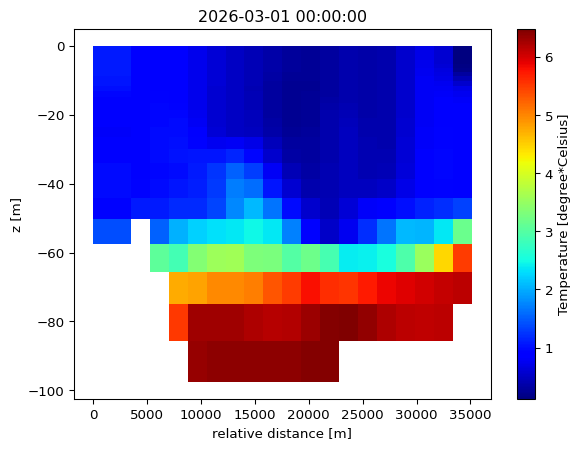

In [11]:
ds_back["Temperature"].isel(time=0).plot();

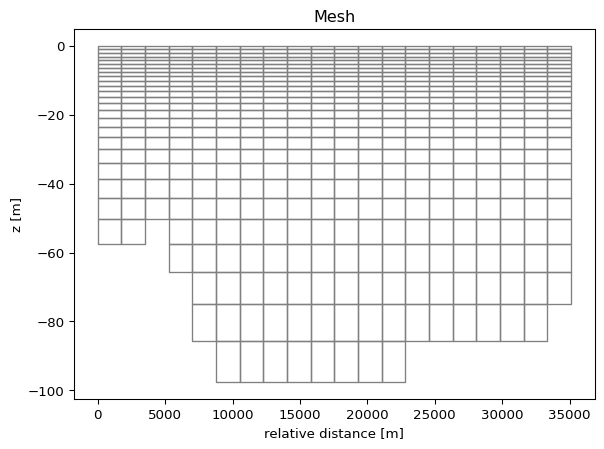

In [12]:
ds_back.geometry.plot.mesh();